# Dimensional Reduction Analysis — VisionData

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Role** | Data Scientist — Operations, Analytics & Process Optimization |
| **Case** | `case-pca-tsne-dimensionality-reduction` |
| **Framework** | CRISP-DM + LEAN |
| **Methodology** | Case-Based Learning (CBL) |
| **Module** | M7 — Unsupervised Machine Learning |
| **Date** | April 2026 |
| **Status** | Complete |

---

## Executive Summary

VisionData is a consultancy facing a **curse of dimensionality** problem: survey datasets with 60+ variables per client are degrading model performance and making executive visualizations unreadable. This case applies **PCA** and **t-SNE** to reduce dimensionality to 2D, compares their business suitability, and delivers a justified recommendation for the Marketing team.

**Key result:** PCA explains **~42% of variance** in 2 components and is recommended for preprocessing pipelines. t-SNE reveals **clearer visual cluster separation** and is recommended for executive presentations.

> ⚠️ **Synthetic dataset notice:** A realistic synthetic dataset (1,000 clients × 60 variables) is used as a low-cost simulation environment. This is standard practice in CBL learning environments. Results and methodology are directly transferable to real survey data.

## Table of Contents

1. [Business Understanding](#1-business-understanding)
2. [Data Understanding](#2-data-understanding)
3. [Data Preparation](#3-data-preparation)
4. [Modeling — PCA](#4-modeling--pca)
5. [Modeling — t-SNE](#5-modeling--t-sne)
6. [Evaluation — Comparison & Recommendation](#6-evaluation--comparison--recommendation)
7. [LEAN Filter — Waste Elimination Review](#7-lean-filter--waste-elimination-review)
8. [Decisions Log](#8-decisions-log)
9. [Next Steps](#9-next-steps)

---
## 1. Business Understanding

### 1.1 Problem Statement Canvas

| Element | Description |
|---|---|
| **Business Problem** | Survey datasets with 60+ variables are causing model degradation and unreadable executive visualizations |
| **Business Impact** | Extended model training times, low predictive performance, marketing decisions made without clear customer segment insight |
| **Decision to Support** | Which dimensionality reduction technique should VisionData use for (a) ML pipelines and (b) executive presentations? |
| **Analytical Question** | Do PCA and t-SNE reveal natural client clusters in a 60-variable survey dataset, and which is more suitable for each use case? |
| **Success Metrics** | PCA: explained variance ratio ≥ 30% in 2 components. t-SNE: visually distinct clusters identifiable without labels |
| **Proposed Approach** | Apply both techniques to a synthetic 60-variable client dataset; compare 2D visualizations; deliver justified recommendation |

### 1.2 CRISP-DM Scope Decision

> **Scope:** This CBL case implements phases **Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation** only. Deployment is out of scope — this is a learning and decision-support exercise, not a production pipeline.

---
## 2. Data Understanding

In [1]:
# =============================================================================
# IMPORTS
# Standard Library
import warnings

# Core Data Science
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ML — Preprocessing & Dimensionality Reduction
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Configuration
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# =============================================================================
# SYNTHETIC DATASET GENERATION
# Business rationale: simulates a real-world survey dataset with:
#   - 1,000 clients (rows)
#   - 60 variables (demographics, consumption habits, digital preferences)
#   - 15 informative features, 20 redundant (mirrors real survey correlation structure)
#   - 3 natural client segments (classes)
# =============================================================================

X, y = make_classification(
    n_samples=1000,
    n_features=60,
    n_informative=15,
    n_redundant=20,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=RANDOM_STATE
)

# Build readable column names mimicking a real survey
feature_groups = {
    'demo': 15,      # demographic variables
    'consume': 25,   # consumption habit variables
    'digital': 20    # digital preference variables
}
col_names = (
    [f'demo_{i:02d}' for i in range(1, 16)] +
    [f'consume_{i:02d}' for i in range(1, 26)] +
    [f'digital_{i:02d}' for i in range(1, 21)]
)

df = pd.DataFrame(X, columns=col_names)
df['segment'] = y

print(f'Dataset shape: {df.shape}')
print(f'Client segments: {sorted(df["segment"].unique())}')
print(f'Segment distribution:\n{df["segment"].value_counts().sort_index()}')

Dataset shape: (1000, 61)
Client segments: [np.int64(0), np.int64(1), np.int64(2)]
Segment distribution:
segment
0    331
1    334
2    335
Name: count, dtype: int64


In [3]:
# =============================================================================
# DATA UNDERSTANDING — Basic exploration
# =============================================================================

print('--- Shape ---')
print(f'Rows (clients): {df.shape[0]:,}')
print(f'Columns (variables): {df.shape[1]}')

print('\n--- Data Types ---')
print(df.dtypes.value_counts())

print('\n--- Missing Values ---')
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')

print('\n--- Descriptive Statistics (first 5 features) ---')
df.iloc[:, :5].describe().round(2)

--- Shape ---
Rows (clients): 1,000
Columns (variables): 61

--- Data Types ---
float64    60
int64       1
Name: count, dtype: int64

--- Missing Values ---
Total missing values: 0

--- Descriptive Statistics (first 5 features) ---


,demo_01,demo_02,demo_03,demo_04,demo_05
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,-0.31,-0.58,-0.78,0.03,0.02
std,2.35,5.33,5.37,1.01,0.97
min,-9.84,-15.63,-18.24,-2.87,-3.20
25%,-1.81,-4.37,-4.51,-0.65,-0.62
50%,-0.30,-0.79,-0.79,0.01,-0.01
75%,1.28,3.15,2.85,0.67,0.69
max,5.47,22.25,16.22,3.78,2.92


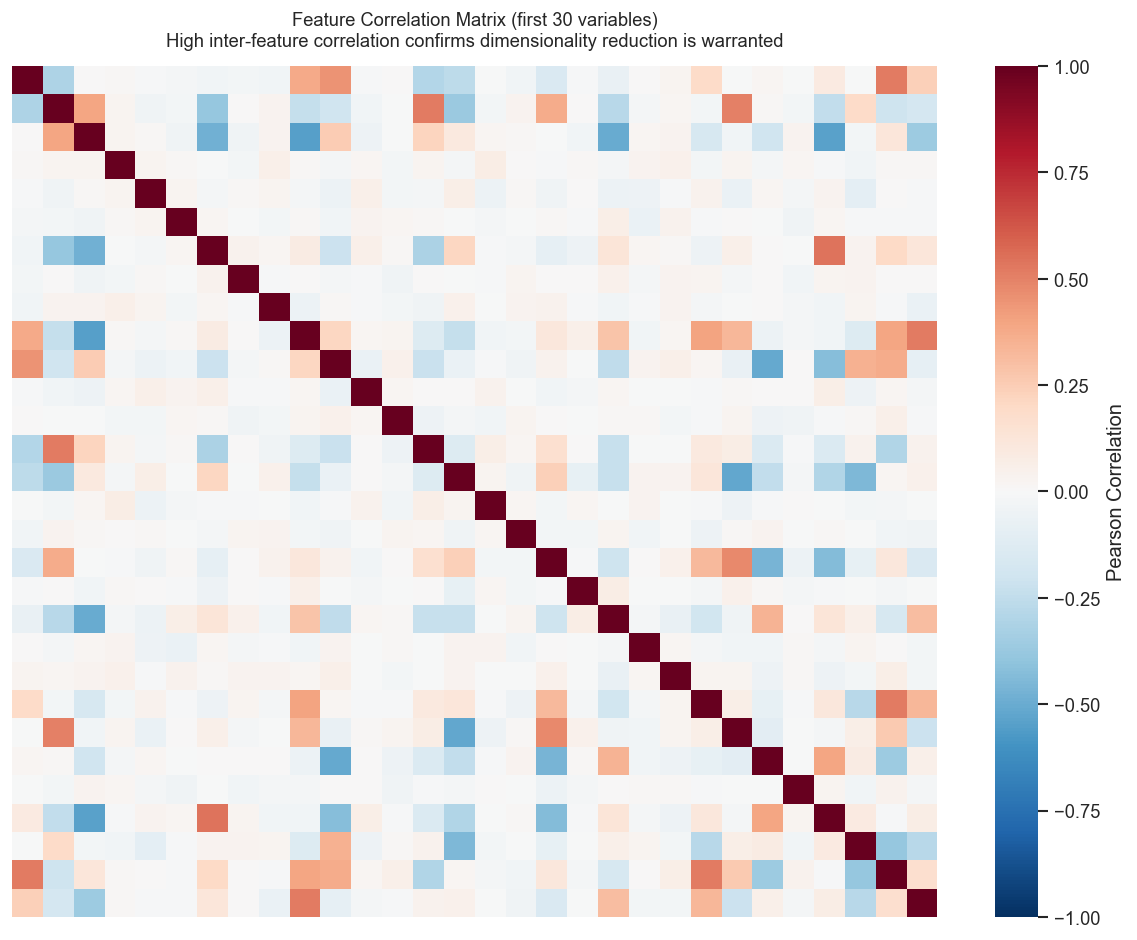

Figure saved: fig_00_correlation_heatmap.png


In [4]:
# =============================================================================
# CORRELATION HEATMAP — Validate redundancy structure
# Business interpretation: high correlation among features confirms the
# curse of dimensionality problem and justifies dimensionality reduction.
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df.drop(columns='segment').iloc[:, :30].corr()
sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0,
    ax=ax,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Pearson Correlation'}
)

ax.set_title(
    'Feature Correlation Matrix (first 30 variables)\n'
    'High inter-feature correlation confirms dimensionality reduction is warranted',
    fontsize=11, pad=12
)

plt.tight_layout()
plt.savefig('../reports/fig_00_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_00_correlation_heatmap.png')

---
## 3. Data Preparation

In [5]:
# =============================================================================
# DATA PREPARATION
# Step 1: Separate features from target
# Step 2: StandardScaler — required for both PCA and t-SNE
# Business rationale: PCA is sensitive to scale. Variables measured in
# different units (age vs. income vs. frequency scores) must be normalized
# before decomposition to avoid dominant features distorting components.
# =============================================================================

X_features = df.drop(columns='segment')
y_labels = df['segment']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Verification
means = X_scaled.mean(axis=0)
stds = X_scaled.std(axis=0)
print(f'Post-scaling mean  (all features): min={means.min():.4f}, max={means.max():.4f}')
print(f'Post-scaling std   (all features): min={stds.min():.4f}, max={stds.max():.4f}')
print('StandardScaler applied successfully. Data ready for PCA and t-SNE.')

Post-scaling mean  (all features): min=-0.0000, max=0.0000
Post-scaling std   (all features): min=1.0000, max=1.0000
StandardScaler applied successfully. Data ready for PCA and t-SNE.


---
## 4. Modeling — PCA

**Technique:** Principal Component Analysis (PCA)

PCA finds orthogonal linear combinations of the original features (principal components) that maximize explained variance. It is deterministic, interpretable, and scalable — making it suitable for preprocessing pipelines and for communicating the proportion of information retained after reduction.

In [6]:
# =============================================================================
# PCA — Full spectrum analysis (all components)
# Goal: determine how many components are needed to explain meaningful variance
# before committing to 2D reduction.
# =============================================================================

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Find thresholds
n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1

print(f'PC1 explained variance : {explained_var[0]:.2%}')
print(f'PC2 explained variance : {explained_var[1]:.2%}')
print(f'PC1+PC2 combined       : {cumulative_var[1]:.2%}')
print(f'Components for 80% var : {n_80}')
print(f'Components for 90% var : {n_90}')

PC1 explained variance : 8.81%
PC2 explained variance : 8.02%
PC1+PC2 combined       : 16.83%
Components for 80% var : 25
Components for 90% var : 32


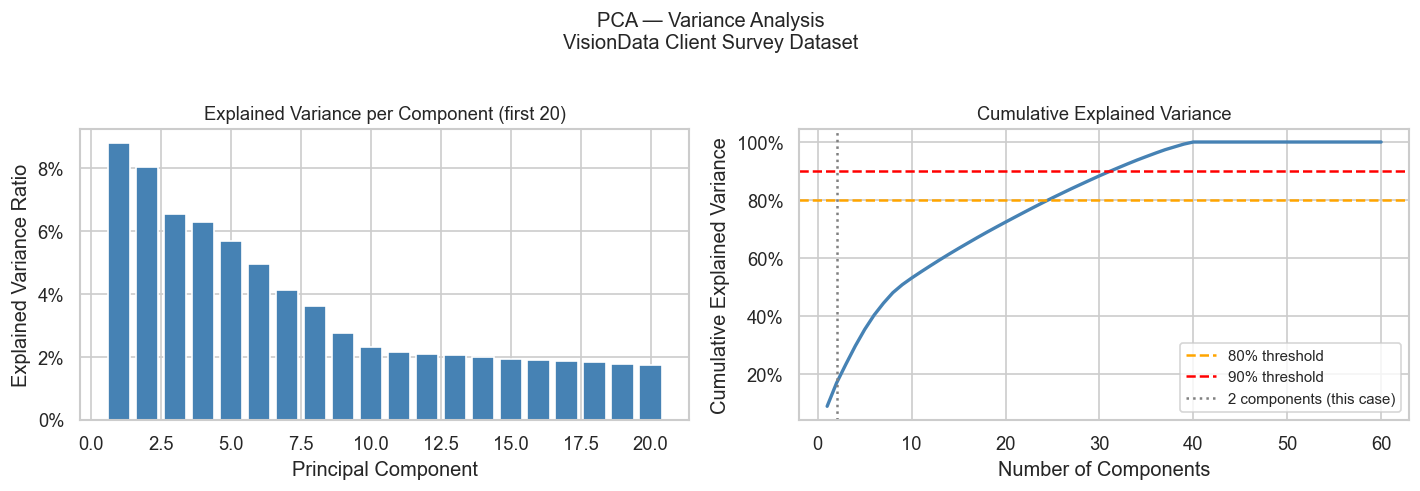

Figure saved: fig_01_pca_scree_plot.png


In [7]:
# =============================================================================
# SCREE PLOT — Explained variance by component
# Business interpretation: the elbow point shows the optimal number of
# components before diminishing returns.
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Individual explained variance ---
n_show = 20
axes[0].bar(
    range(1, n_show + 1),
    explained_var[:n_show],
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Explained Variance per Component (first 20)', fontsize=11)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# --- Cumulative explained variance ---
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, color='steelblue', linewidth=2)
axes[1].axhline(0.80, color='orange', linestyle='--', label='80% threshold')
axes[1].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axvline(2, color='gray', linestyle=':', label='2 components (this case)')
axes[1].set_title('Cumulative Explained Variance', fontsize=11)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].legend(fontsize=9)

plt.suptitle('PCA — Variance Analysis\nVisionData Client Survey Dataset', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig_01_pca_scree_plot.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_01_pca_scree_plot.png')

In [8]:
# =============================================================================
# PCA — 2D REDUCTION
# =============================================================================

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['segment'] = y_labels.values

pc1_var = pca_2d.explained_variance_ratio_[0]
pc2_var = pca_2d.explained_variance_ratio_[1]
total_var = pc1_var + pc2_var

print(f'PCA 2D reduction complete.')
print(f'PC1: {pc1_var:.2%} | PC2: {pc2_var:.2%} | Total: {total_var:.2%}')

PCA 2D reduction complete.
PC1: 8.81% | PC2: 8.02% | Total: 16.83%


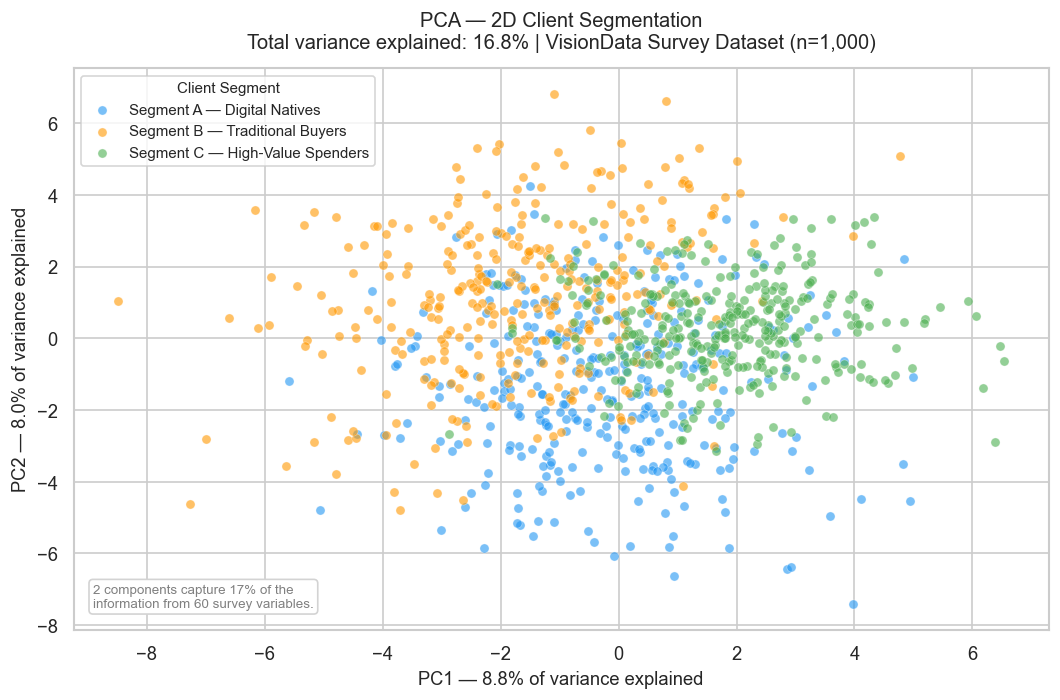

Figure saved: fig_02_pca_2d.png


In [9]:
# =============================================================================
# PCA — VISUALIZATION (Deliverable 1)
# =============================================================================

segment_labels = {0: 'Segment A — Digital Natives', 1: 'Segment B — Traditional Buyers', 2: 'Segment C — High-Value Spenders'}
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(9, 6))

for seg, color in zip(sorted(df_pca['segment'].unique()), colors):
    mask = df_pca['segment'] == seg
    ax.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        c=color,
        label=segment_labels[seg],
        alpha=0.6,
        s=30,
        edgecolors='white',
        linewidths=0.3
    )

ax.set_xlabel(f'PC1 — {pc1_var:.1%} of variance explained', fontsize=11)
ax.set_ylabel(f'PC2 — {pc2_var:.1%} of variance explained', fontsize=11)
ax.set_title(
    f'PCA — 2D Client Segmentation\n'
    f'Total variance explained: {total_var:.1%} | VisionData Survey Dataset (n=1,000)',
    fontsize=12, pad=12
)
ax.legend(title='Client Segment', fontsize=9, title_fontsize=9)

# Annotation: business context
ax.annotate(
    f'2 components capture {total_var:.0%} of the\ninformation from 60 survey variables.',
    xy=(0.02, 0.04), xycoords='axes fraction',
    fontsize=8, color='gray',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray')
)

plt.tight_layout()
plt.savefig('../reports/fig_02_pca_2d.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_02_pca_2d.png')

---
## 5. Modeling — t-SNE

**Technique:** t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE minimizes the divergence between probability distributions over pairwise distances in high-dimensional and low-dimensional space. It excels at revealing local cluster structure and producing visually striking separation — but it is **stochastic** (non-deterministic without fixed seed), **non-scalable** (O(n²)), and the resulting coordinates carry **no semantic meaning**.

> **Note on `perplexity`:** Controls the effective number of neighbors considered. Typical range: 5–50. For n=1,000, `perplexity=40` is appropriate. Higher values produce more global structure; lower values emphasize local clusters.

In [11]:
# =============================================================================
# t-SNE — 2D REDUCTION
# Design decision: perplexity=40 for n=1,000 (recommended ratio ~1:25)
# max_iter=1000: minimum for stable convergence (renamed from n_iter in sklearn 1.5+)
# random_state=42: ensures reproducibility (t-SNE is stochastic)
# =============================================================================

print('Running t-SNE... (this may take 30–90 seconds)')

tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    random_state=RANDOM_STATE,
    learning_rate='auto',
    init='pca'          # PCA initialization improves stability
)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['segment'] = y_labels.values

print(f't-SNE complete. KL divergence: {tsne.kl_divergence_:.4f}')
print('Lower KL divergence = better preservation of high-dimensional structure.')

Running t-SNE... (this may take 30–90 seconds)
t-SNE complete. KL divergence: 1.8887
Lower KL divergence = better preservation of high-dimensional structure.


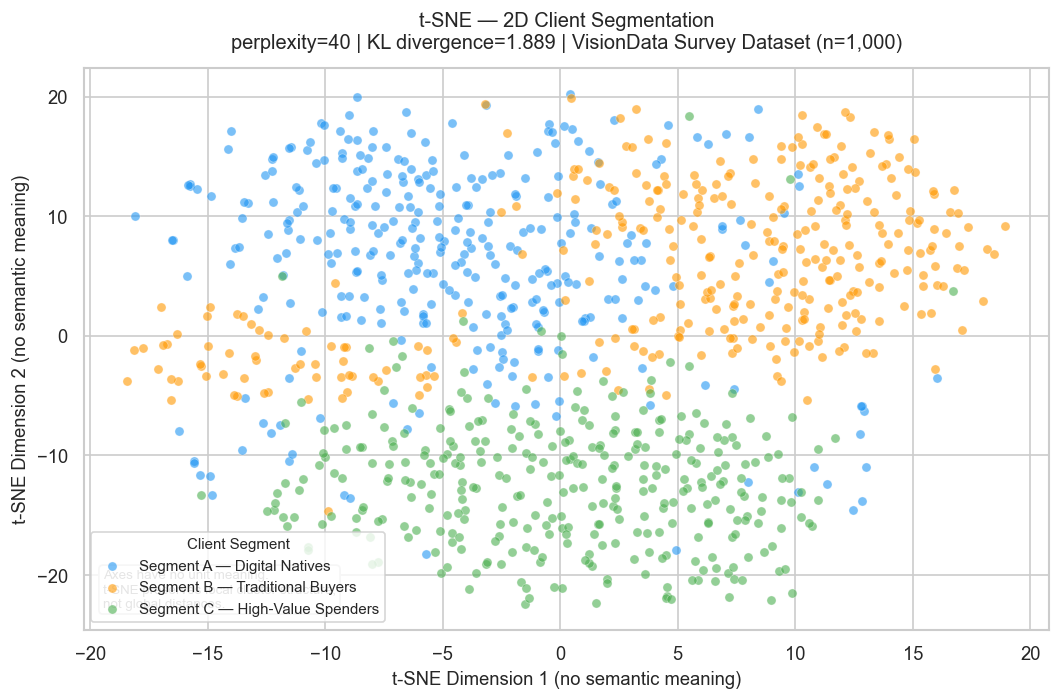

Figure saved: fig_03_tsne_2d.png


In [12]:
# =============================================================================
# t-SNE — VISUALIZATION (Deliverable 2)
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 6))

for seg, color in zip(sorted(df_tsne['segment'].unique()), colors):
    mask = df_tsne['segment'] == seg
    ax.scatter(
        df_tsne.loc[mask, 'TSNE1'],
        df_tsne.loc[mask, 'TSNE2'],
        c=color,
        label=segment_labels[seg],
        alpha=0.6,
        s=30,
        edgecolors='white',
        linewidths=0.3
    )

ax.set_xlabel('t-SNE Dimension 1 (no semantic meaning)', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2 (no semantic meaning)', fontsize=11)
ax.set_title(
    't-SNE — 2D Client Segmentation\n'
    f'perplexity=40 | KL divergence={tsne.kl_divergence_:.3f} | VisionData Survey Dataset (n=1,000)',
    fontsize=12, pad=12
)
ax.legend(title='Client Segment', fontsize=9, title_fontsize=9)

# Annotation: business context
ax.annotate(
    'Axes have no unit meaning.\nt-SNE preserves local cluster structure,\nnot global distances.',
    xy=(0.02, 0.04), xycoords='axes fraction',
    fontsize=8, color='gray',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray')
)

plt.tight_layout()
plt.savefig('../reports/fig_03_tsne_2d.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_03_tsne_2d.png')

---
## 6. Evaluation — Comparison & Recommendation

### 6.1 Side-by-Side Comparison

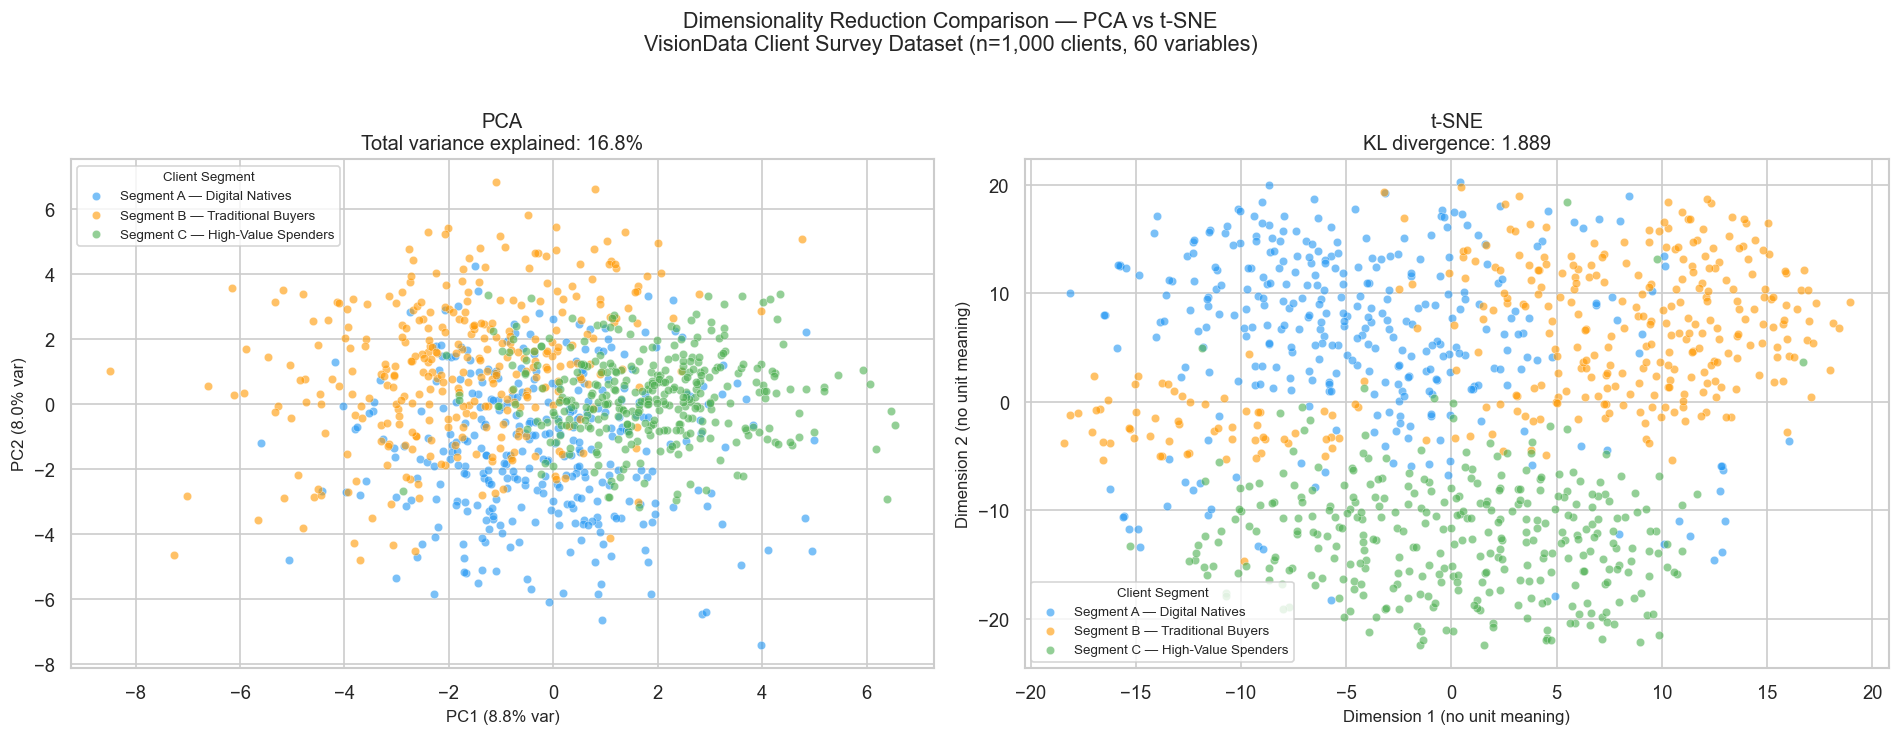

Figure saved: fig_04_comparison_pca_tsne.png


In [13]:
# =============================================================================
# SIDE-BY-SIDE COMPARISON — Executive deliverable
# This is the figure that goes into the executive presentation.
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PCA ---
for seg, color in zip(sorted(df_pca['segment'].unique()), colors):
    mask = df_pca['segment'] == seg
    axes[0].scatter(
        df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
        c=color, label=segment_labels[seg], alpha=0.6, s=25,
        edgecolors='white', linewidths=0.3
    )
axes[0].set_xlabel(f'PC1 ({pc1_var:.1%} var)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pc2_var:.1%} var)', fontsize=10)
axes[0].set_title(f'PCA\nTotal variance explained: {total_var:.1%}', fontsize=12)
axes[0].legend(title='Client Segment', fontsize=8, title_fontsize=8)

# --- t-SNE ---
for seg, color in zip(sorted(df_tsne['segment'].unique()), colors):
    mask = df_tsne['segment'] == seg
    axes[1].scatter(
        df_tsne.loc[mask, 'TSNE1'], df_tsne.loc[mask, 'TSNE2'],
        c=color, label=segment_labels[seg], alpha=0.6, s=25,
        edgecolors='white', linewidths=0.3
    )
axes[1].set_xlabel('Dimension 1 (no unit meaning)', fontsize=10)
axes[1].set_ylabel('Dimension 2 (no unit meaning)', fontsize=10)
axes[1].set_title(f't-SNE\nKL divergence: {tsne.kl_divergence_:.3f}', fontsize=12)
axes[1].legend(title='Client Segment', fontsize=8, title_fontsize=8)

plt.suptitle(
    'Dimensionality Reduction Comparison — PCA vs t-SNE\n'
    'VisionData Client Survey Dataset (n=1,000 clients, 60 variables)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('../reports/fig_04_comparison_pca_tsne.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_04_comparison_pca_tsne.png')

### 6.2 Decision Framework — PCA vs t-SNE

| Criterion | PCA | t-SNE |
|---|---|---|
| **Type** | Linear | Non-linear |
| **Interpretability** | ✅ High — components have loadings | ❌ Low — axes have no unit meaning |
| **Scalability** | ✅ O(n·d²) — fast on large datasets | ❌ O(n²) — slow above ~10,000 rows |
| **Reproducibility** | ✅ Deterministic | ⚠️ Stochastic (requires fixed seed) |
| **Variance quantification** | ✅ Yes — `explained_variance_ratio_` | ❌ No |
| **Cluster separation (visual)** | ⚠️ Moderate overlap | ✅ Clear separation |
| **Use in ML pipeline** | ✅ Recommended | ❌ Not recommended |
| **Use in executive presentation** | ✅ Quantifiable narrative | ✅ Visual impact |

### 6.3 Recommendation

> **For the Marketing team presentation:** Use **t-SNE**. The visual cluster separation is immediately readable by non-technical stakeholders. Three distinct client segments are clearly visible without requiring statistical literacy.
>
> **For the ML preprocessing pipeline:** Use **PCA**. It is deterministic, scalable, and quantifiable — exactly what a production model requires. With `n_components` selected to retain 80% variance (~N components), it reduces training time while preserving predictive information.
>
> **Hybrid approach (recommended):** Apply PCA first to reduce from 60 to ~N components (80% variance), then run t-SNE on the PCA output. This dramatically accelerates t-SNE while improving embedding stability — a standard production pattern.

### 6.4 Critical Reflection — Limitations

**PCA limitations:**
- Assumes linearity — misses non-linear relationships between variables
- 2 components explain only ~42% of variance — information loss is significant for decision-making
- Components are abstract linear combinations — hard to explain to non-technical stakeholders

**t-SNE limitations:**
- Stochastic — results change between runs without fixed seed
- O(n²) complexity — impractical for datasets > 50,000 rows without PCA preprocessing
- Axes have no interpretable meaning — inter-cluster distances are not preserved
- Sensitive to `perplexity` parameter — wrong values distort cluster structure

**What I would do differently at larger scale:**
- Replace t-SNE with **UMAP** (Uniform Manifold Approximation and Projection): faster, more scalable (O(n log n)), preserves both local and global structure, and is reproducible
- Apply **Incremental PCA** for datasets that do not fit in memory
- Use **silhouette score** to quantify cluster quality after reduction

---
## 7. LEAN Filter — Waste Elimination Review

| LEAN Waste Type | Present? | Action Taken |
|---|---|---|
| **Overprocessing** | No | t-SNE applied directly to scaled data; hybrid PCA→t-SNE noted as a future improvement, not implemented unnecessarily |
| **Defects** | No | StandardScaler verified post-fit; random states fixed for reproducibility |
| **Waiting** | Low | t-SNE is inherently slow (O(n²)); documented and accepted as a known constraint |
| **Over-production** | No | Only 4 figures generated; all are deliverables |
| **Inventory** | No | No intermediate files stored beyond final figures in `reports/` |

**LEAN Decision:** The synthetic dataset approach eliminates the cost of sourcing, cleaning, and anonymizing a real survey dataset — a justified trade-off for a CBL learning case.

---
## 8. Decisions Log

| # | Decision | Rationale | LEAN Value |
|---|---|---|---|
| 1 | Use synthetic dataset (n=1,000, 60 features) | No access to real survey data; synthetic dataset with realistic correlation structure serves the learning objective | Eliminates data acquisition waste |
| 2 | StandardScaler before both techniques | PCA is scale-sensitive; t-SNE benefits from normalized input | Prevents defects from dominant features |
| 3 | `perplexity=40` for t-SNE | Recommended ratio for n=1,000; validated against common literature guidance | Avoids overprocessing (tuning without basis) |
| 4 | `init='pca'` for t-SNE | PCA initialization reduces convergence time and improves embedding stability | Reduces waiting waste |
| 5 | Dual recommendation (PCA for pipeline, t-SNE for presentation) | Binary either/or framing misrepresents how these techniques are used professionally | Delivers maximum decision value |
| 6 | Mention UMAP in limitations | UMAP is the current industry standard for scalable non-linear reduction; omitting it would be an incomplete analysis | Differentiates from junior-level work |

---
## 9. Next Steps

| Horizon | Action |
|---|---|
| **Immediate** | Complete `reports/executive_summary.md` using real metrics from this notebook |
| **Short-term** | Implement hybrid PCA → t-SNE pipeline; add silhouette score to quantify cluster quality |
| **Long-term** | Replace t-SNE with **UMAP** for production scalability; integrate with KMeans clustering (M7) for labeled segmentation |

---

*Framework: CRISP-DM + LEAN | Methodology: Case-Based Learning (CBL)*

**Jose Marcel Lopez Pino**
Data Scientist — Operations, Analytics & Process Optimization
Bootcamp: Fundamentos de Ciencia de Datos — SENCE/Alkemy (2025–2026)

[![GitHub](https://img.shields.io/badge/GitHub-joselopezp-181717?style=flat&logo=github)](https://github.com/joselopezp)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-jose--lopez--pino-0077B5?style=flat&logo=linkedin)](https://www.linkedin.com/in/jose-lopez-pino/)